# A-S backtest — orig vs our (side-by-side)

Loads two runs and visualizes them in parallel:
- **orig**: `scripts.backtest_orig_as` (constants-only A-S, GLFT baseline)
- **our**: `scripts.backtest_our_as` (model-driven μ/σ/κ from heads)

Set `ORIG_DIR` and `OUR_DIR` to the runs you want to compare.

In [5]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

RUN_NAME = "SBER_2024-03-22_060-120"
ORIG_DIR = Path(f"../runs/backtest_orig_as/{RUN_NAME}")
OUR_DIR  = Path(f"../runs/backtest_our_as/{RUN_NAME}")

def load(run_dir):
    return {
        "steps":   pl.read_parquet(run_dir / "steps.parquet"),
        "fills":   pl.read_parquet(run_dir / "fills.parquet"),
        "summary": json.loads((run_dir / "summary.json").read_text()),
    }

orig = load(ORIG_DIR)
our  = load(OUR_DIR)

def short(s):
    return {
        "interval":   f"{s['interval_start_min']:.0f}-{s['interval_end_min']:.0f} min",
        "n_steps":    s["n_steps"],
        "n_quotes":   s["n_quotes_placed"],
        "n_fills":    s["n_fills"],
        "final_pos":  s["final_position"],
        "PnL":        round(s["pnl"], 2),
        "fees":       round(s["final_fee"], 4),
        "max_inv":    s["max_abs_position"],
        "book_spread":round(s["mean_book_spread"], 4),
    }

print("orig (constants):\n", json.dumps(short(orig["summary"]), indent=2))
print("\nour  (model):\n",   json.dumps(short(our["summary"]),  indent=2))

orig (constants):
 {
  "interval": "60-120 min",
  "n_steps": 3601,
  "n_quotes": 6431,
  "n_fills": 130,
  "final_pos": 0.0,
  "PnL": 37.34,
  "fees": -0.0033,
  "max_inv": 51.0,
  "book_spread": 0.01
}

our  (model):
 {
  "interval": "60-120 min",
  "n_steps": 3601,
  "n_quotes": 6598,
  "n_fills": 411,
  "final_pos": 0.0,
  "PnL": -2.03,
  "fees": -0.0097,
  "max_inv": 2.0,
  "book_spread": 0.01
}


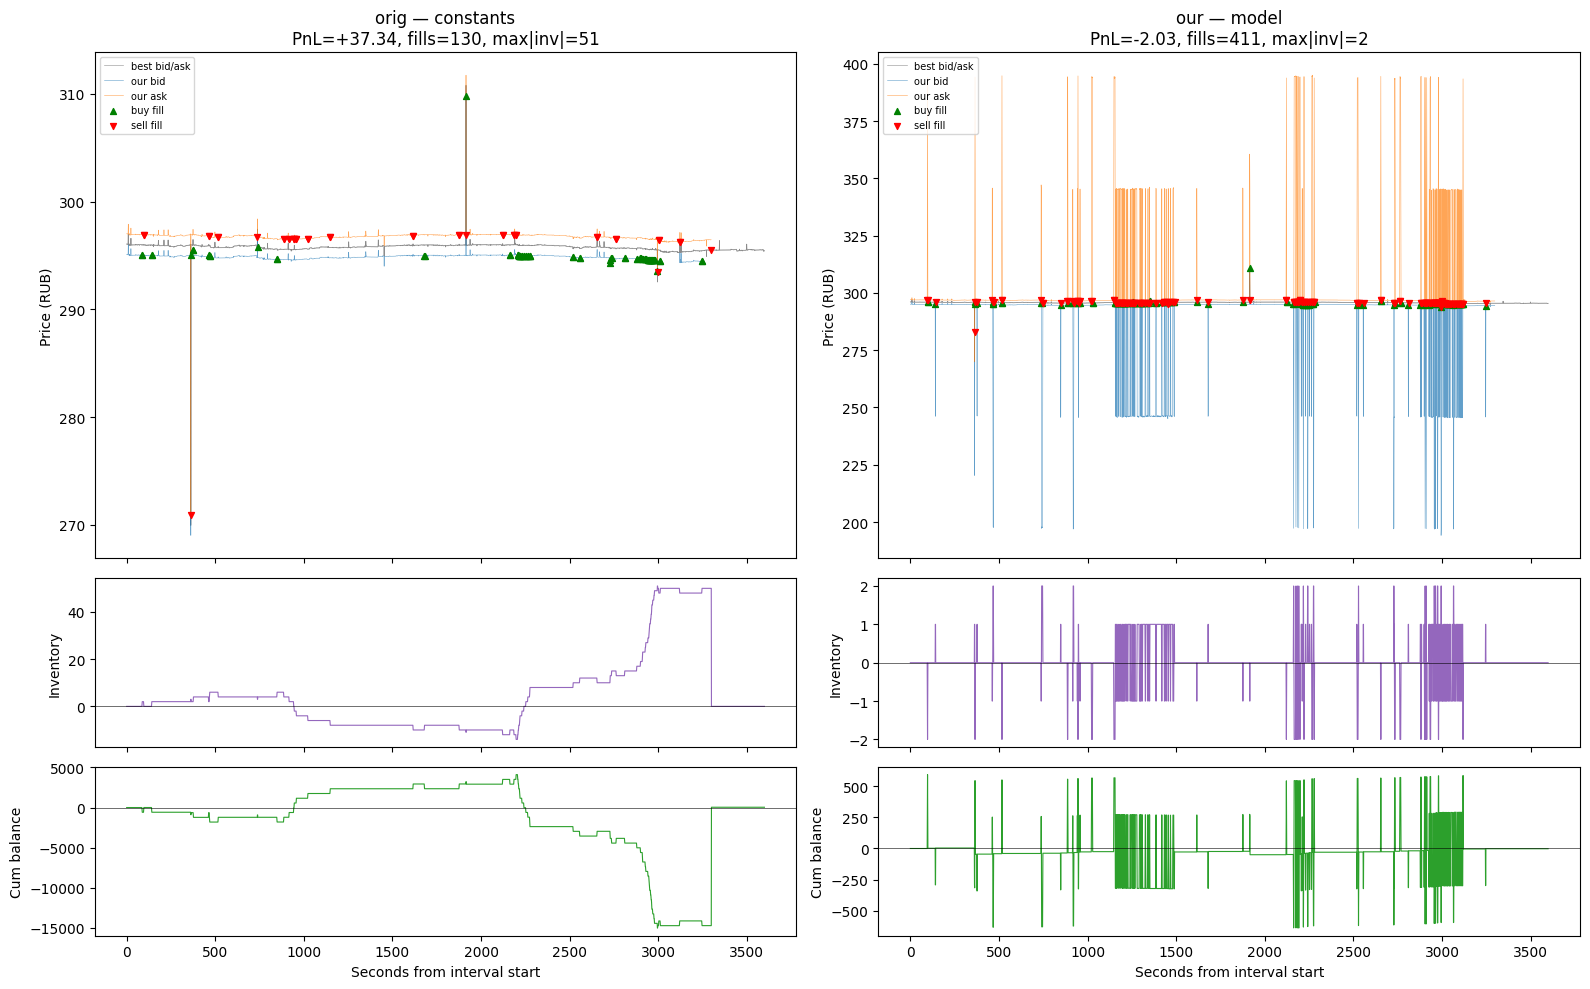

In [6]:
# 3-row × 2-col grid: orig in left column, our in right column.
def plot_run(run, ax_price, ax_inv, ax_pnl, title):
    steps = run["steps"]
    fills = run["fills"]
    s = run["summary"]
    t0 = int(steps["ts"][0])
    t  = ((steps["ts"] - t0) / 1e9).to_numpy()

    ax_price.plot(t, steps["best_bid"], color="grey", lw=0.5, alpha=0.7, label="best bid/ask")
    ax_price.plot(t, steps["best_ask"], color="grey", lw=0.5, alpha=0.7)
    ax_price.plot(t, steps["our_bid"],  color="tab:blue",   lw=0.4, alpha=0.7, label="our bid")
    ax_price.plot(t, steps["our_ask"],  color="tab:orange", lw=0.4, alpha=0.7, label="our ask")
    buys  = fills.filter(pl.col("side") == "buy")
    sells = fills.filter(pl.col("side") == "sell")
    if len(buys):
        ax_price.scatter(((buys["ts"]  - t0) / 1e9).to_numpy(), buys["price"].to_numpy(),
                          s=18, color="green", marker="^", zorder=5, label="buy fill")
    if len(sells):
        ax_price.scatter(((sells["ts"] - t0) / 1e9).to_numpy(), sells["price"].to_numpy(),
                          s=18, color="red",   marker="v", zorder=5, label="sell fill")
    ax_price.legend(loc="upper left", fontsize=7)
    ax_price.set_title(f"{title}\nPnL={s['pnl']:+.2f}, fills={s['n_fills']}, max|inv|={s['max_abs_position']:.0f}")
    ax_price.set_ylabel("Price (RUB)")

    ax_inv.plot(t, steps["position"], color="tab:purple", lw=0.8)
    ax_inv.axhline(0, color="black", lw=0.4)
    ax_inv.set_ylabel("Inventory")

    ax_pnl.plot(t, steps["balance"], color="tab:green", lw=0.8)
    ax_pnl.axhline(0, color="black", lw=0.4)
    ax_pnl.set_ylabel("Cum balance")
    ax_pnl.set_xlabel("Seconds from interval start")

fig, axes = plt.subplots(
    3, 2, figsize=(16, 10), sharex="col",
    gridspec_kw={"height_ratios": [3, 1, 1]},
)
plot_run(orig, axes[0, 0], axes[1, 0], axes[2, 0], "orig — constants")
plot_run(our,  axes[0, 1], axes[1, 1], axes[2, 1], "our — model")
plt.tight_layout()
plt.show()

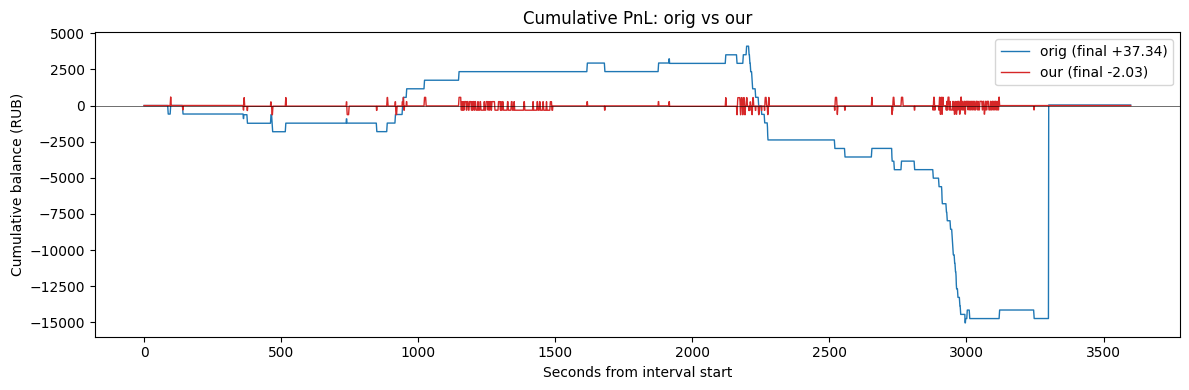

In [7]:
# Cumulative PnL overlay — both runs on the same axis.
fig, ax = plt.subplots(figsize=(12, 4))
for run, label, color in [(orig, "orig", "tab:blue"), (our, "our", "tab:red")]:
    steps = run["steps"]
    t0 = int(steps["ts"][0])
    t  = ((steps["ts"] - t0) / 1e9).to_numpy()
    ax.plot(t, steps["balance"], color=color, lw=1.0,
            label=f"{label} (final {run['summary']['pnl']:+.2f})")
ax.axhline(0, color="black", lw=0.4)
ax.legend()
ax.set_xlabel("Seconds from interval start")
ax.set_ylabel("Cumulative balance (RUB)")
ax.set_title("Cumulative PnL: orig vs our")
plt.tight_layout()
plt.show()

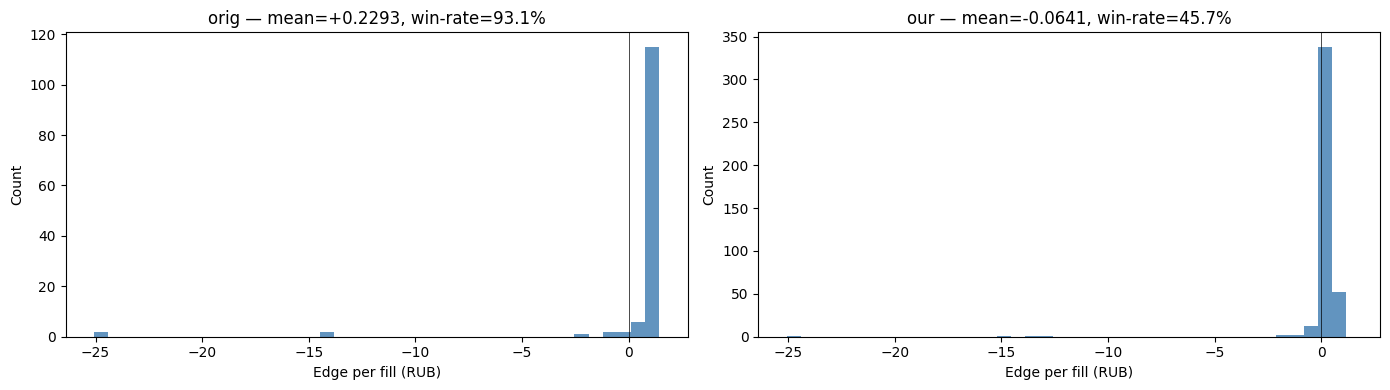

In [8]:
# Per-fill edge: positive = we collected spread relative to mid at fill time.
def edge_per_fill(run):
    steps = run["steps"]
    fills = run["fills"]
    if len(fills) == 0:
        return None
    step_ts  = steps["ts"].to_numpy()
    step_mid = ((steps["best_bid"] + steps["best_ask"]) / 2).to_numpy()
    idx = np.searchsorted(step_ts, fills["ts"].to_numpy()).clip(0, len(step_ts) - 1)
    fill_mid  = step_mid[idx]
    fill_px   = fills["price"].to_numpy()
    fill_side = fills["side"].to_numpy()
    return np.where(fill_side == "sell", fill_px - fill_mid, fill_mid - fill_px)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for ax, run, label in [(axes[0], orig, "orig"), (axes[1], our, "our")]:
    edge = edge_per_fill(run)
    if edge is None:
        ax.text(0.5, 0.5, "no fills", ha="center", va="center", transform=ax.transAxes)
        continue
    ax.hist(edge, bins=40, color="steelblue", alpha=0.85)
    ax.axvline(0, color="black", lw=0.5)
    ax.set_title(f"{label} — mean={edge.mean():+.4f}, win-rate={(edge > 0).mean():.1%}")
    ax.set_xlabel("Edge per fill (RUB)")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

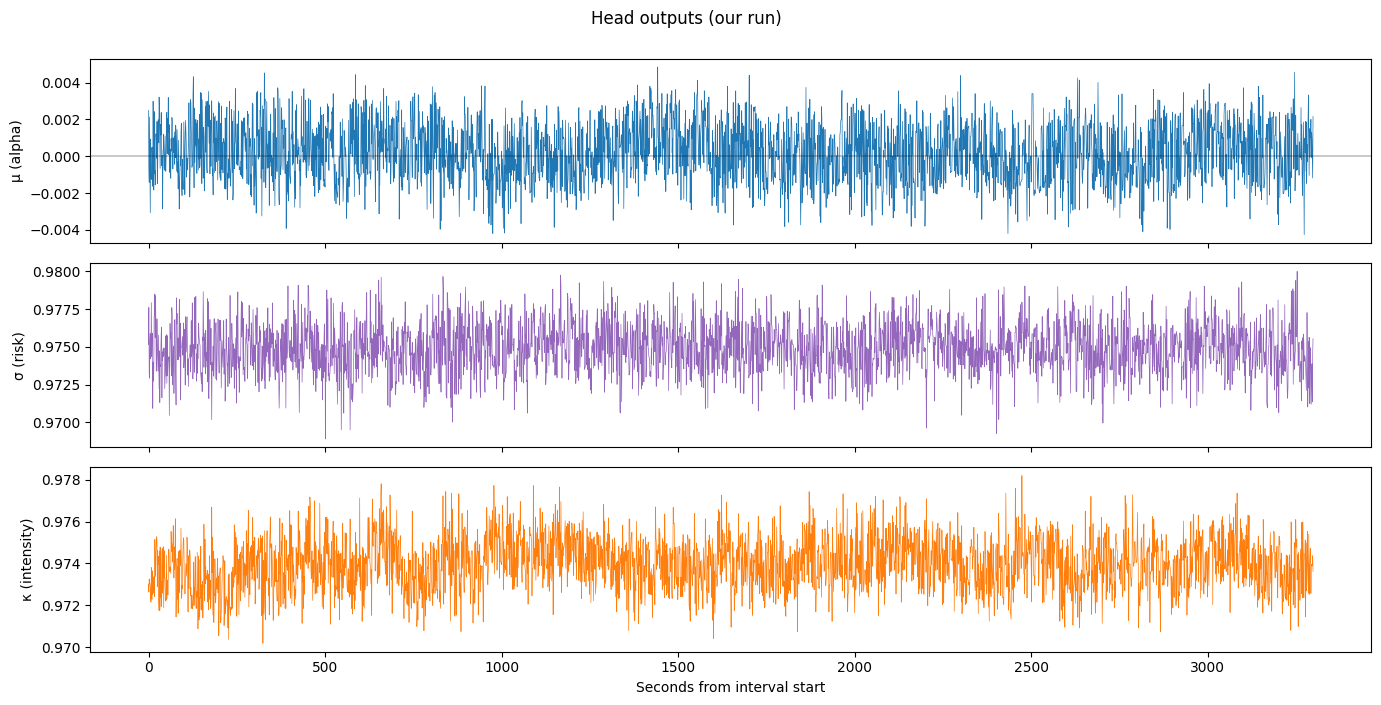

In [9]:
# Head outputs over time (only present in our run).
if "mu" in our["steps"].columns:
    steps = our["steps"]
    t0 = int(steps["ts"][0])
    t  = ((steps["ts"] - t0) / 1e9).to_numpy()
    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
    axes[0].plot(t, steps["mu"],    color="tab:blue",   lw=0.5)
    axes[0].set_ylabel("μ (alpha)")
    axes[0].axhline(0, color="black", lw=0.3)
    axes[1].plot(t, steps["sigma"], color="tab:purple", lw=0.5)
    axes[1].set_ylabel("σ (risk)")
    axes[2].plot(t, steps["kappa"], color="tab:orange", lw=0.5)
    axes[2].set_ylabel("κ (intensity)")
    axes[2].set_xlabel("Seconds from interval start")
    fig.suptitle("Head outputs (our run)", y=1.0)
    plt.tight_layout()
    plt.show()
else:
    print("our run has no μ/σ/κ columns — was it produced by backtest_our_as?")